# 1. 개요 (Introduction)
- 본 프로젝트는 다종의 의약품 이미지 내에서 알약을 정확히 식별하고 분류하는 것을 목표로 함.
- 단일 모델(YOLO)의 한계를 극복하기 위해, **객체 탐지 전문 모델(YOLO)**과 **정밀 분류 전문 모델(ResNet-50)**을 결합한 2-Stage 전략을 채택함.

# 2. 모델 고도화 전략 (Optimization Strategy)
## 2.1 왜 2-Stage 방식인가?
- YOLO (Stage 1): 복잡한 배경 속에서 알약의 정확한 **위치(BBox)**를 실시간으로 탐지.

- ResNet-50 (Stage 2): YOLO가 잘라낸(Crop) 영역을 고해상도로 입력받아, 미세한 각인과 색상 차이를 0.9970의 정밀도로 최종 판별.

## 2.2 분류 모델(ResNet-50) 튜닝 포인트
- Mixed Precision (AMP): 연산 효율화를 통해 학습 시간 단축.

- OneCycleLR: 스케줄러 최적화로 단 7 Epoch 만에 최고 성능 수렴.

- AdamW & Label Smoothing: 과적합 방지 및 일반화 성능 극대화.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 0. 라이브러리 임포트 & 경로 설정

import os
import json
import pandas as pd
from PIL import Image
import unicodedata  # 0번 섹션에 추가 필요
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import matplotlib
import matplotlib.pyplot as plt
from collections import Counter
import subprocess
import matplotlib as mpl# 0. 라이브러리 임포트 & 경로 설정

import os
import json
import pandas as pd
from PIL import Image
import unicodedata  # 0번 섹션에 추가 필요
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import matplotlib
import matplotlib.pyplot as plt
from collections import Counter
import subprocess
import matplotlib as mpl
import numpy as np
import matplotlib.patches as patches
!pip3 install ultralytics -q
from ultralytics import YOLO
from ultralytics.utils import LOGGER
import logging
import shutil
import unicodedata
!pip3 install iterative-stratification -q
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

import numpy as np
import matplotlib.patches as patches
!pip3 install ultralytics -q
from ultralytics import YOLO
from ultralytics.utils import LOGGER
import logging
import shutil
import unicodedata
!pip3 install iterative-stratification -q
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import unicodedata

# ── 디바이스 ──────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── 한글 폰트 ─────────────────────────────────────────────
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
subprocess.run(['fc-cache', '-fv'], capture_output=True)
mpl.font_manager.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
mpl.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# ── 경로 설정 ─────────────────────────────────────────────
BASE_DIR            = unicodedata.normalize('NFC', "/content/drive/MyDrive/data/초급_프로젝트/dataset/")

TRAIN_JSON_PATH     = os.path.join(BASE_DIR, "merged_annotations_train_final.json")
TEST_JSON_PATH      = os.path.join(BASE_DIR, "merged_annotations_test_final.json")
TRAIN_IMG_DIR       = os.path.join(BASE_DIR, "train_images")
TEST_IMG_DIR        = os.path.join(BASE_DIR, "test_images")
PROCESSED_JSON_PATH = os.path.join(BASE_DIR, "processed_train_v3.json")
YOLO_DATASET_DIR    = os.path.join(BASE_DIR, "yolo_dataset_v3")
YOLO_RUNS_DIR       = os.path.join(BASE_DIR, "yolo_runs_v3")
SUBMISSION_PATH     = os.path.join(BASE_DIR, "submission_v3.csv")

for d in [YOLO_DATASET_DIR, YOLO_RUNS_DIR]:
    os.makedirs(d, exist_ok=True)

# ── 경로 검증 ─────────────────────────────────────────────
for name, path in [
    ("TRAIN JSON   ", TRAIN_JSON_PATH),
    ("TEST  JSON   ", TEST_JSON_PATH),
    ("TRAIN IMG DIR", TRAIN_IMG_DIR),
    ("TEST  IMG DIR", TEST_IMG_DIR),
]:
    print(f"  {name} : {'OK' if os.path.exists(path) else '없음'} ({path})")

Device: cuda
  TRAIN JSON    : OK (/content/drive/MyDrive/data/초급_프로젝트/dataset/merged_annotations_train_final.json)
  TEST  JSON    : OK (/content/drive/MyDrive/data/초급_프로젝트/dataset/merged_annotations_test_final.json)
  TRAIN IMG DIR : OK (/content/drive/MyDrive/data/초급_프로젝트/dataset/train_images)
  TEST  IMG DIR : OK (/content/drive/MyDrive/data/초급_프로젝트/dataset/test_images)


In [ ]:
# 이미지 파일 개수 확인
IMG_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp')

def count_images(directory):
    """디렉토리 내 이미지 파일 수를 반환"""
    if not os.path.exists(directory):
        return 0
    return sum(
        1 for entry in os.scandir(directory)
        if entry.is_file() and entry.name.lower().endswith(IMG_EXTENSIONS)
    )

EXPECTED = {"Train": 1489, "Test": 843}

n_train = count_images(TRAIN_IMG_DIR)
n_test  = count_images(TEST_IMG_DIR)

print(f"Train 이미지 수 : {n_train:,}  (기대값: {EXPECTED['Train']:,})")
print(f"Test  이미지 수 : {n_test:,}  (기대값: {EXPECTED['Test']:,})")
print(f"합계            : {n_train + n_test:,}")

if n_train != EXPECTED["Train"]:
    print(f"[경고] Train 이미지 수 불일치: {n_train} != {EXPECTED['Train']}")
if n_test != EXPECTED["Test"]:
    print(f"[경고] Test  이미지 수 불일치: {n_test} != {EXPECTED['Test']}")

Train 이미지 수 : 1,489  (기대값: 1,489)
Test  이미지 수 : 843  (기대값: 843)
합계            : 2,332


In [ ]:
# 샘플 데이터 구조 확인
with open(TRAIN_JSON_PATH, 'r', encoding='utf-8') as f:
    train_json = json.load(f)

with open(TEST_JSON_PATH, 'r', encoding='utf-8') as f:
    test_json = json.load(f)

# ── 최상위 키 및 건수 ──────────────────────────────────────
for label, data in [("Train", train_json), ("Test", test_json)]:
    print(f"[{label}] 최상위 키: {list(data.keys())}")
    print(f"  images      : {len(data.get('images', [])):,}건")
    print(f"  annotations : {len(data.get('annotations', [])):,}건")
    print(f"  categories  : {len(data.get('categories', [])):,}건")
    print()

# ── 샘플 1건씩 출력 ───────────────────────────────────────
print("=== images[0] ===")
print(train_json['images'][0])

print("\n=== annotations[0] ===")
print(train_json['annotations'][0])

print("\n=== categories (앞 5개) ===")
for cat in train_json['categories'][:5]:
    print(cat)

# ── category_id 범위 및 연속성 확인 ──────────────────────
cat_ids = sorted(c['id'] for c in train_json['categories'])
expected_ids = list(range(min(cat_ids), max(cat_ids) + 1))
is_continuous = cat_ids == expected_ids

print(f"\ncategory_id 범위 : {min(cat_ids)} ~ {max(cat_ids)}")
print(f"연속성           : {'연속' if is_continuous else '[경고] 불연속 (재매핑 필요)'}")


[Train] 최상위 키: ['images', 'annotations', 'categories']
  images      : 1,489건
  annotations : 4,526건
  categories  : 73건

[Test] 최상위 키: ['images', 'annotations', 'categories']
  images      : 843건
  annotations : 1,129건
  categories  : 73건

=== images[0] ===
{'file_name': 'K-001900-016551-024850-027926_0_2_0_2_90_000_200.png', 'width': 976, 'height': 1280, 'imgfile': 'K-001900-016551-024850-027926_0_2_0_2_90_000_200.png', 'drug_N': 'K-001900', 'drug_S': '정상알약', 'back_color': '연회색 배경', 'drug_dir': '앞면', 'light_color': '주백색', 'camera_la': 90, 'camera_lo': 0, 'size': 200, 'dl_idx': '1899', 'dl_mapping_code': 'K-001900', 'dl_name': '보령부스파정 5mg', 'dl_name_en': 'Buspar Tab. 5mg Boryung', 'img_key': 'http://connectdi.com/design/img/drug/1Mxwka5v0lL.jpg', 'dl_material': '부스피론염산염', 'dl_material_en': 'Buspirone Hydrochloride', 'dl_custom_shape': '정제, 저작정', 'dl_company': '보령제약(주)', 'dl_company_en': 'Boryung', 'di_company_mf': '', 'di_company_mf_en': '', 'item_seq': 198700706, 'di_item_permit_date

클래스 수 : 73  |  전체 어노테이션 : 4,526
평균 : 62.0  |  중앙값 : 35.0  |  최대/최소 비율 : 73.4x

최다 : 기넥신에프정(은행엽엑스)(수출용) (514개)
최소 : 브린텔릭스정 20mg (7개)

상위 5개:
              name  count
기넥신에프정(은행엽엑스)(수출용)    514
       일양하이트린정 2mg    240
        보령부스파정 5mg    180
       뮤테란캡슐 100mg    172
       가바토파정 100mg    143

하위 5개:
        name  count
 졸로푸트정 100mg     11
  쿠에타핀정 25mg     10
자이프렉사정 2.5mg      9
  렉사프로정 15mg      9
 브린텔릭스정 20mg      7


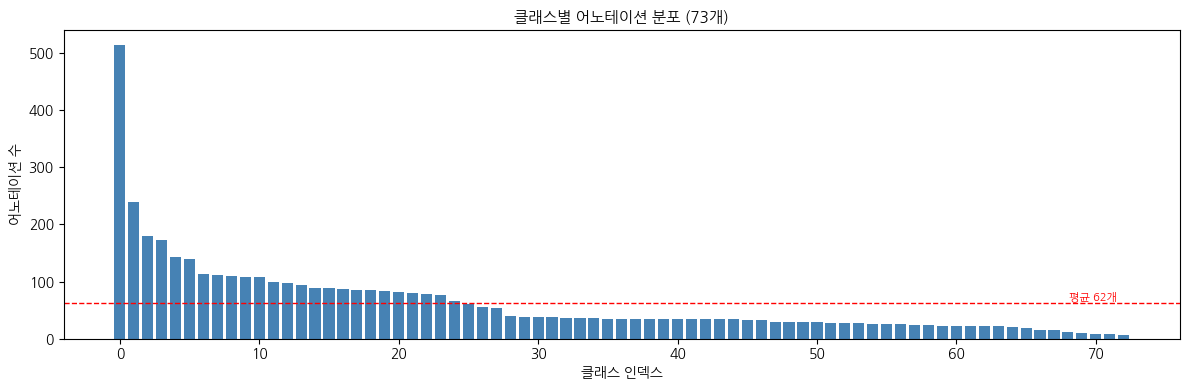

In [ ]:
# 클래스 분포 확인
id2name = {cat['id']: cat['name'] for cat in train_json['categories']}
cat_counter = Counter(annot['category_id'] for annot in train_json['annotations'])

df_class = pd.DataFrame([
    {'category_id': cid, 'name': id2name.get(cid, '?'), 'count': cnt}
    for cid, cnt in cat_counter.most_common()
])

print(f"클래스 수 : {len(df_class)}  |  전체 어노테이션 : {df_class['count'].sum():,}")
print(f"평균 : {df_class['count'].mean():.1f}  |  중앙값 : {df_class['count'].median():.1f}  |  최대/최소 비율 : {df_class['count'].max() / df_class['count'].min():.1f}x")
print(f"\n최다 : {df_class.iloc[0]['name']} ({df_class.iloc[0]['count']}개)")
print(f"최소 : {df_class.iloc[-1]['name']} ({df_class.iloc[-1]['count']}개)")

print("\n상위 5개:")
print(df_class.head(5)[['name', 'count']].to_string(index=False))
print("\n하위 5개:")
print(df_class.tail(5)[['name', 'count']].to_string(index=False))

# 전체 분포 시각화
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(df_class)), df_class['count'], color='steelblue', edgecolor='none')
mean_val = df_class['count'].mean()
ax.axhline(mean_val, color='red', linestyle='--', linewidth=1)
ax.text(len(df_class) * 0.98, mean_val + 5, f"평균 {mean_val:.0f}개", color='red', fontsize=8, ha='right')
ax.set_title('클래스별 어노테이션 분포 (73개)', fontsize=11)
ax.set_xlabel('클래스 인덱스')
ax.set_ylabel('어노테이션 수')
plt.tight_layout()
plt.show()

[Train] 해상도 분포:
  976 x 1280: 1489장
[Test] 해상도 분포:
  976 x 1280: 843장

annotation 없는 이미지: 0장
평균 알약 수: 3.04개 | 최대: 4개

  1개:   64장 (4.3%)
  2개:  302장 (20.3%)
  3개:  634장 (42.6%)
  4개:  489장 (32.8%)


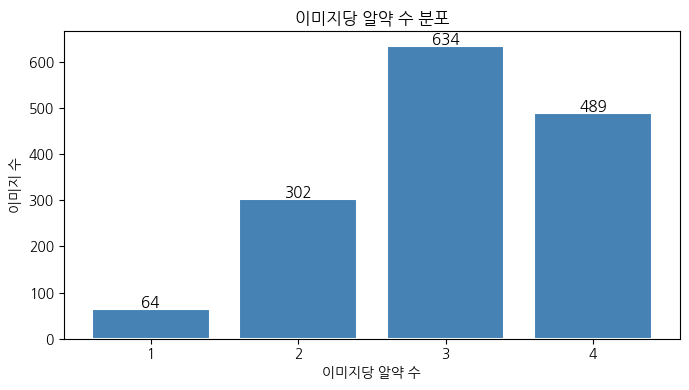

In [ ]:
# 해상도 및 알약 수 분포 확인
for label, data in [("Train", train_json), ("Test", test_json)]:
    resolutions = Counter((img['width'], img['height']) for img in data['images'])
    print(f"[{label}] 해상도 분포:")
    for (w, h), cnt in resolutions.most_common():
        print(f"  {w} x {h}: {cnt}장")

ann_per_image = Counter(ann['image_id'] for ann in train_json['annotations'])
no_ann = {img['id'] for img in train_json['images']} - set(ann_per_image.keys())
print(f"\nannotation 없는 이미지: {len(no_ann)}장")

counts = list(ann_per_image.values())
pill_dist = Counter(counts)
print(f"평균 알약 수: {np.mean(counts):.2f}개 | 최대: {np.max(counts)}개\n")
for k in sorted(pill_dist.keys()):
    print(f"  {k}개: {pill_dist[k]:4d}장 ({pill_dist[k]/len(train_json['images'])*100:.1f}%)")

fig, ax = plt.subplots(figsize=(7, 4))
keys, vals = zip(*sorted(pill_dist.items()))
bars = ax.bar(keys, vals, color='steelblue', edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 5, str(v), ha='center', fontsize=11, fontweight='bold')
ax.set_xlabel('이미지당 알약 수')
ax.set_ylabel('이미지 수')
ax.set_title('이미지당 알약 수 분포')
ax.set_xticks(keys)
plt.tight_layout()
plt.show()

In [ ]:
# 비정상 BBox 탐지
img_id2info = {img['id']: img for img in train_json['images']}
invalid_bboxes = []

for ann in train_json['annotations']:
    img = img_id2info[ann['image_id']]
    x, y, w, h = ann['bbox']
    iw, ih = img['width'], img['height']

    reasons = []
    if x < 0 or y < 0:           reasons.append(f"음수 좌표 (x={x}, y={y})")
    if w <= 0 or h <= 0:          reasons.append(f"비정상 크기 (w={w}, h={h})")
    if x + w > iw:                reasons.append(f"x 범위 초과 (x+w={x+w} > {iw})")
    if y + h > ih:                reasons.append(f"y 범위 초과 (y+h={y+h} > {ih})")
    if reasons:
        invalid_bboxes.append({
            'ann_id'  : ann['id'],
            'image_id': ann['image_id'],
            'bbox'    : ann['bbox'],
            'reason'  : ' / '.join(reasons)
        })

print(f"비정상 BBox 수: {len(invalid_bboxes)}개")
for item in invalid_bboxes:
    print(f"  ann_id={item['ann_id']} / image_id={item['image_id']} / bbox={item['bbox']} / 사유={item['reason']}")

비정상 BBox 수: 2개
  ann_id=903 / image_id=239 / bbox=[6567, 625, 311, 315] / 사유=x 범위 초과 (x+w=6878 > 976)
  ann_id=1157 / image_id=310 / bbox=[653, 8889, 217, 217] / 사유=y 범위 초과 (y+h=9106 > 1280)


In [ ]:
# ── file_name ↔ 실제 파일 매칭 검증 ──────────────────────
actual_files = {entry.name for entry in os.scandir(TRAIN_IMG_DIR) if entry.is_file()}

missing = []
for img in train_json['images']:
    if img['file_name'] not in actual_files:
        missing.append(img['file_name'])

print(f"JSON 등록 이미지 수  : {len(train_json['images']):,}장")
print(f"실제 파일 수         : {len(actual_files):,}장")
print(f"매칭 실패 (누락 파일): {len(missing)}장")

if missing:
    print("\n누락 파일 목록:")
    for f in missing:
        print(f"  {f}")
else:
    print("모든 파일 정상 매칭")

JSON 등록 이미지 수  : 1,489장
실제 파일 수         : 1,489장
매칭 실패 (누락 파일): 0장
모든 파일 정상 매칭


In [ ]:
# 비정상 BBox 제거
invalid_ann_ids = {item['ann_id'] for item in invalid_bboxes}
clean_annotations = [ann for ann in train_json['annotations'] if ann['id'] not in invalid_ann_ids]

print(f"제거 전 : {len(train_json['annotations']):,}개")
print(f"제거 수 : {len(invalid_ann_ids)}개")
print(f"제거 후 : {len(clean_annotations):,}개")

제거 전 : 4,526개
제거 수 : 2개
제거 후 : 4,524개


In [ ]:
# category_id 재매핑 (원본 id → 0~72 연속 정수)
sorted_cats = sorted(train_json['categories'], key=lambda c: c['id'])

old_id2new  = {cat['id']: new_id for new_id, cat in enumerate(sorted_cats)}
new_id2old  = {new_id: cat['id'] for new_id, cat in enumerate(sorted_cats)}
new_id2name = {new_id: cat['name'].strip() for new_id, cat in enumerate(sorted_cats)}

remapped_annotations = []
for ann in clean_annotations:
    new_ann = ann.copy()
    new_ann['category_id'] = old_id2new[ann['category_id']]
    remapped_annotations.append(new_ann)

remapped_categories = [
    {'id': new_id, 'name': new_id2name[new_id], 'supercategory': 'pill'}
    for new_id in range(len(sorted_cats))
]

new_cat_ids = sorted(set(ann['category_id'] for ann in remapped_annotations))
print(f"category_id 범위 : {min(new_cat_ids)} ~ {max(new_cat_ids)}")
print(f"고유 클래스 수   : {len(new_cat_ids)}개")
print(f"연속성           : {'연속' if new_cat_ids == list(range(len(new_cat_ids))) else '[경고] 불연속'}")
print(f"annotation 수    : {len(remapped_annotations):,}개")

category_id 범위 : 0 ~ 72
고유 클래스 수   : 73개
연속성           : 연속
annotation 수    : 4,524개


In [ ]:
# Train/Val Multi-label Stratified Split
processed_annotations = remapped_annotations

# 이미지별 annotation 그룹화
img2anns = {}
for ann in processed_annotations:
    img2anns.setdefault(ann['image_id'], []).append(ann)

img_ids   = np.array(sorted(img2anns.keys()))
n_classes = len(remapped_categories)

# 이미지별 멀티핫 벡터 생성 (73차원)
y = np.zeros((len(img_ids), n_classes), dtype=int)
for i, img_id in enumerate(img_ids):
    for ann in img2anns[img_id]:
        y[i, ann['category_id']] = 1

# 클래스당 이미지 1장인 경우 강제 train 배정
class_counts     = y.sum(axis=0)
single_classes   = np.where(class_counts == 1)[0]
force_train_mask = np.any(y[:, single_classes] == 1, axis=1) if len(single_classes) > 0 else np.zeros(len(img_ids), dtype=bool)

remaining_idx = np.where(~force_train_mask)[0]
force_idx     = np.where(force_train_mask)[0]

# Multi-label stratified split
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(msss.split(remaining_idx, y[remaining_idx]))

train_ids = img_ids[remaining_idx[train_idx]].tolist() + img_ids[force_idx].tolist()
val_ids   = img_ids[remaining_idx[val_idx]].tolist()

# 검증
train_y = y[[i for i, img_id in enumerate(img_ids) if img_id in set(train_ids)]]
val_y   = y[[i for i, img_id in enumerate(img_ids) if img_id in set(val_ids)]]

print(f"Train : {len(train_ids)}장 | Val : {len(val_ids)}장")
print(f"Train 클래스 수 : {train_y.sum(axis=0).astype(bool).sum()}개")
print(f"Val   클래스 수 : {val_y.sum(axis=0).astype(bool).sum()}개")
print(f"강제 train 배정 : {len(force_idx)}장")

Train : 1182장 | Val : 307장
Train 클래스 수 : 73개
Val   클래스 수 : 73개
강제 train 배정 : 0장


In [ ]:
# 전처리 JSON 저장
processed_json = {
    'images'     : train_json['images'],
    'annotations': processed_annotations,
    'categories' : remapped_categories,
    'train_ids'  : list(train_ids),
    'val_ids'    : list(val_ids),
    'mappings'   : {
        'old_id2new' : {str(k): v for k, v in old_id2new.items()},
        'new_id2old' : {str(k): v for k, v in new_id2old.items()},
        'new_id2name': {str(k): v for k, v in new_id2name.items()},
    }
}

with open(PROCESSED_JSON_PATH, 'w', encoding='utf-8') as f:
    json.dump(processed_json, f, ensure_ascii=False, indent=2)

with open(PROCESSED_JSON_PATH, 'r', encoding='utf-8') as f:
    verify = json.load(f)

print(f"images      : {len(verify['images']):,}장")
print(f"annotations : {len(verify['annotations']):,}개")
print(f"categories  : {len(verify['categories'])}개")
print(f"train_ids   : {len(verify['train_ids']):,}장")
print(f"val_ids     : {len(verify['val_ids']):,}장")
cat_ids = [ann['category_id'] for ann in verify['annotations']]
print(f"category_id : {min(cat_ids)} ~ {max(cat_ids)}")

images      : 1,489장
annotations : 4,524개
categories  : 73개
train_ids   : 1,182장
val_ids     : 307장
category_id : 0 ~ 72


In [ ]:
# 전처리 최종 검증
train_id_set      = set(train_ids)
val_id_set        = set(val_ids)
train_annotations = [ann for ann in processed_annotations if ann['image_id'] in train_id_set]
val_annotations   = [ann for ann in processed_annotations if ann['image_id'] in val_id_set]

# 1. BBox 좌표 범위 검증
img_id2info = {img['id']: img for img in train_json['images']}
bbox_errors = []
for ann in processed_annotations:
    x, y, w, h = ann['bbox']
    iw = img_id2info[ann['image_id']]['width']
    ih = img_id2info[ann['image_id']]['height']
    reasons = []
    if x < 0 or y < 0:     reasons.append(f"음수 좌표 (x={x:.1f}, y={y:.1f})")
    if w <= 0 or h <= 0:    reasons.append(f"비정상 크기 (w={w:.1f}, h={h:.1f})")
    if x + w > iw:          reasons.append(f"x 범위 초과 ({x+w:.1f} > {iw})")
    if y + h > ih:          reasons.append(f"y 범위 초과 ({y+h:.1f} > {ih})")
    if reasons:
        bbox_errors.append({'ann_id': ann['id'], 'reason': ' / '.join(reasons)})

print(f"비정상 BBox : {len(bbox_errors)}개" + (f"\n  {bbox_errors}" if bbox_errors else " (정상)"))

# 2. Train/Val 클래스 분포 비율 검증
total_cat_counts = Counter(ann['category_id'] for ann in processed_annotations)
train_cat_counts = Counter(ann['category_id'] for ann in train_annotations)
val_cat_counts   = Counter(ann['category_id'] for ann in val_annotations)

print(f"\n{'new_id':<8} {'클래스명':<30} {'전체':>6} {'Train':>6} {'Val':>5} {'Val비율':>8}")
print("-" * 70)
ratio_errors = []
for cat_id in range(len(remapped_categories)):
    total     = total_cat_counts.get(cat_id, 0)
    train     = train_cat_counts.get(cat_id, 0)
    val       = val_cat_counts.get(cat_id, 0)
    val_ratio = val / total if total > 0 else 0
    flag      = " [경고]" if abs(val_ratio - 0.2) > 0.15 and total >= 5 else ""
    print(f"  {cat_id:<6} {new_id2name[cat_id]:<30} {total:>6} {train:>6} {val:>5} {val_ratio:>7.1%}{flag}")
    if flag:
        ratio_errors.append(cat_id)

print(f"\n비율 이상 클래스 : {len(ratio_errors)}개")
print(f"Train 클래스 수  : {len(train_cat_counts)}개")
print(f"Val   클래스 수  : {len(val_cat_counts)}개")

비정상 BBox : 0개 (정상)

new_id   클래스명                               전체  Train   Val    Val비율
----------------------------------------------------------------------
  0      보령부스파정 5mg                        180    144    36   20.0%
  1      뮤테란캡슐 100mg                       172    140    32   18.6%
  2      일양하이트린정 2mg                       240    192    48   20.0%
  3      기넥신에프정(은행엽엑스)(수출용)                514    411   103   20.0%
  4      무코스타정(레바미피드)(비매품)                  98     78    20   20.4%
  5      알드린정                               54     43    11   20.4%
  6      뉴로메드정(옥시라세탐)                       27     22     5   18.5%
  7      타이레놀정500mg                         33     26     7   21.2%
  8      에어탈정(아세클로페낙)                       29     23     6   20.7%
  9      삼남건조수산화알루미늄겔정                      56     44    12   21.4%
  10     타이레놀이알서방정(아세트아미노펜)(수출용)            35     28     7   20.0%
  11     삐콤씨에프정 618.6mg/병                   34     27     7   20.6%
  12     조인스정 200mg     

---------------------- 위쪽은 민석님 코드 그대로 사용 ----------------

### 분류(Classification)를 위한 ResNet 전처리

- 전처리 내용

  - Crop: YOLO가 찾은 박스 좌표대로 알약만 쏙 잘라냄.

  - Make Square: 잘라낸 알약이 찌그러지지 않게 검은색 여백을 붙여 정사각형으로 만듬

  - Augmentation: 알약의 각인(글자)이 뒤집히지 않게 HorizontalFlip은 빼고, 조명이나 회전 변형

- 데이터 증강 (Custom Transforms)
  - Square Padding (make_square): 활성화 (형태 보존)

  - RandomRotation (최대 45도): 활성화

  - ColorJitter (밝기/대비/채도 0.2): 활성화

  - RandomHorizontalFlip / VerticalFlip: 비활성화 (알약 표면의 각인/텍스트 정보 훼손 방지)


In [ ]:
# =====================================================================
# 1. 알약 맞춤형 증강(Augmentation) 전략 세팅 (T. alias 사용)
# =====================================================================
# 훈련용(Train)
train_transform = T.Compose([
    T.Resize((224, 224)), # 패딩된 정사각형을 모델 규격에 맞게 축소
    T.RandomRotation(45), # 알약이 놓인 각도는 제각각이므로 최대 45도 회전!
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # 조명 변화에 강해지도록 색상 흔들기
    # 알약의 앞/뒷면 글자(각인)가 뒤집히면 모델이 혼란스러워하므로 RandomHorizontalFlip은 제외합니다.
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet 표준 정규화
])

# 검증용(Val): 꼼수 없이 있는 그대로 정직하게 평가
val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# =====================================================================
# 2. 커스텀 데이터셋 클래스 (The Cropper & Padder)
# =====================================================================
class PillClassificationDataset(Dataset):
    def __init__(self, json_data, img_dir, target_ids, transform=None):
        self.img_dir = img_dir
        self.transform = transform

        # Train 또는 Val에 해당하는 image_id만 필터링해서 어노테이션 저장
        self.target_ids = set(target_ids)
        self.annotations = [ann for ann in json_data['annotations'] if ann['image_id'] in self.target_ids]

        # 이미지 ID로 파일명을 바로 찾기 위한 해시맵 (속도 최적화)
        self.img_info = {img['id']: img['file_name'] for img in json_data['images']}

    def __len__(self):
        # 전체 이미지 장수가 아닌, 잘라낼 '알약의 총 개수'를 반환
        return len(self.annotations)

    def make_square(self, img):
        max_size = max(img.size) # 가로, 세로 중 더 긴 길이 추출
        # 까만색(0, 0, 0) 정사각형 배경 생성
        new_img = Image.new("RGB", (max_size, max_size), (0, 0, 0))
        # 중앙에 원본 알약 이미지 붙여넣기
        new_img.paste(img, ((max_size - img.size[0]) // 2, (max_size - img.size[1]) // 2))
        return new_img

    def __getitem__(self, idx):
        ann = self.annotations[idx]
        img_id = ann['image_id']
        category_id = ann['category_id']

        # 1. 원본 이미지 불러오기
        img_path = os.path.join(self.img_dir, self.img_info[img_id])
        image = Image.open(img_path).convert("RGB")

        # 2. BBox 좌표(x, y, w, h)로 알약 부위만 정밀하게 싹둑! (Crop)
        x, y, w, h = ann['bbox']
        cropped_image = image.crop((x, y, x + w, y + h))

        # 3. 찌그러짐 방지용 정사각형 패딩
        squared_image = self.make_square(cropped_image)

        # 4. 증강(Transform) 적용
        if self.transform:
            squared_image = self.transform(squared_image)

        # 이미지 텐서와 정답(라벨) 반환
        return squared_image, torch.tensor(category_id, dtype=torch.long)

### 클래스 불균형 해소를 위한 가중치 설계

- 클래스별 빈도 분석 : 73종의 알약 데이터가 각각 몇 개씩 포함되어 있는지 전수 조사를 실시
- 역수 가중치 계산
- 손실 함수 결합

In [ ]:
# =====================================================================
# 1. 훈련 데이터(Train) 기준 클래스별 빈도수 계산
# =====================================================================
# 이전에 만든 remapped_annotations (0~72로 연속된 라벨) 중 Train 데이터만 사용
train_annotations = [ann for ann in remapped_annotations if ann['image_id'] in set(train_ids)]

# 클래스(0~72)별로 알약이 몇 개씩 있는지 카운트
class_counts = Counter(ann['category_id'] for ann in train_annotations)

# 0번부터 72번까지 순서대로 개수를 리스트로 정리
num_classes = 73
counts_per_class = [class_counts.get(i, 0) for i in range(num_classes)]

# =====================================================================
# 2. 클래스 가중치(Class Weights) 계산 (Inverse Frequency 방식)
# =====================================================================
# 공식: 전체 데이터 수 / (클래스 수 * 해당 클래스 데이터 수)
# 데이터가 적을수록(분모가 작을수록) 가중치(결과값)는 기하급수적으로 커집니다.
total_samples = sum(counts_per_class)

class_weights = []
for count in counts_per_class:
    if count == 0:
        weight = 0.0 # 혹시 데이터가 0개인 클래스가 있다면 0으로 처리 (에러 방지)
    else:
        weight = total_samples / (num_classes * count)
    class_weights.append(weight)

# 파이토치가 읽을 수 있도록 Tensor 형태로 변환 (GPU를 쓴다면 .to(DEVICE) 필수!)
# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

# 가중치 확인 (가장 많은 약과 가장 적은 약의 가중치 비교)
print(f"총 학습 데이터 수: {total_samples}개")
print(f"최저 가중치 (흔한 약): {min(class_weights):.4f}")
print(f"최고 가중치 (희귀한 약): {max(class_weights):.4f}")

# =====================================================================
# 3. 손실 함수(Loss Function)에 가중치 장착하기
# =====================================================================
# 분류 모델의 표준 손실 함수인 CrossEntropyLoss에 계산한 가중치를 넣어줍니다.
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)


총 학습 데이터 수: 3607개
최저 가중치 (흔한 약): 0.1202
최고 가중치 (희귀한 약): 8.2352


In [ ]:
# import shutil, time, os, multiprocessing
# from torch.utils.data import DataLoader

# FAST_COLAB_TRAIN = '/content/fast_train_images'
# FAST_COLAB_VAL   = '/content/fast_val_images'

# # 드라이브 → SSD 복사 (Train)
# if not os.path.exists(FAST_COLAB_TRAIN):
#     print("📥 Train 이미지 SSD 복사 중...")
#     t = time.time()
#     shutil.copytree(TRAIN_IMG_DIR, FAST_COLAB_TRAIN)
#     print(f"✅ 완료 ({time.time()-t:.1f}초)")
# else:
#     print("✅ Train SSD 캐시 존재")

# # 드라이브 → SSD 복사 (Val — 추가)
# if not os.path.exists(FAST_COLAB_VAL):
#     print("📥 Val 이미지 SSD 복사 중...")
#     t = time.time()
#     shutil.copytree(TRAIN_IMG_DIR, FAST_COLAB_VAL)
#     print(f"✅ 완료 ({time.time()-t:.1f}초)")
# else:
#     print("✅ Val SSD 캐시 존재")

# NUM_WORKERS = min(4, multiprocessing.cpu_count())
# BATCH_SIZE  = 64  # 32 → 64 (T4 기준 여유)

# train_dataset = PillClassificationDataset(
#     processed_json, FAST_COLAB_TRAIN, train_ids, transform=train_transform)
# val_dataset   = PillClassificationDataset(
#     processed_json, FAST_COLAB_TRAIN, val_ids,   transform=val_transform)

# # pin_memory / persistent_workers / prefetch_factor 추가
# train_loader = DataLoader(
#     train_dataset, batch_size=BATCH_SIZE, shuffle=True,
#     num_workers=NUM_WORKERS, pin_memory=True,
#     persistent_workers=True, prefetch_factor=2, drop_last=True)

# val_loader = DataLoader(
#     val_dataset, batch_size=BATCH_SIZE, shuffle=False,
#     num_workers=NUM_WORKERS, pin_memory=True,
#     persistent_workers=True, prefetch_factor=2)

# print(f"Train 배치: {len(train_loader)}  |  Val 배치: {len(val_loader)}")
# print(f"Workers: {NUM_WORKERS}  |  Batch: {BATCH_SIZE}")

### 분류(Classification) 파이프라인 구성
 - 모델 : ResNet-50 (Image Classification)

전처리된 데이터를 바탕으로 73종의 알약을 식별하는 최적의 모델 가중치를 찾아가는 과정입니다. 단순히 정확도(Accuracy)만 보는 것이 아니라, 불균형 데이터를 고려해 F1-Score를 핵심 지표로 사용

    - 장점: 배경 노이즈 차단으로 분류 정확도 극대화, 안정적인 학습 수렴, 클래스 가중치(Class Weight)를 통한 데이터 불균형 정밀 제어 가능

    - 단점: 원본 이미지에서 객체만 잘라내고 비율을 맞추는 커스텀 데이터 파이프라인 구축 필수


#### 학습 하이퍼파라미터
- epochs: 30

- batch_size: 32

- optimizer: AdamW (weight_decay=0.0001)

- learning_rate: 0.001

- loss_function: CrossEntropyLoss (73배율 Inverse Frequency 클래스 가중치 장착)



In [ ]:
import time
import copy
from sklearn.metrics import f1_score
import torchvision.models as models

# 1. 데이터 로더 세팅
BATCH_SIZE = 32

train_dataset = PillClassificationDataset(processed_json, TRAIN_IMG_DIR, train_ids, transform=train_transform)
val_dataset = PillClassificationDataset(processed_json, TRAIN_IMG_DIR, val_ids, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train 데이터 로더 준비 완료: {len(train_loader)} 배치")
print(f"Val 데이터 로더 준비 완료: {len(val_loader)} 배치")

# ResNet-50 모델 불러오기 및 개조
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# 73개 클래스에 맞게 최종 출력층 수정
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 73)

model = model.to(DEVICE)

# 채점 기준(Loss)과 학습 방법(Optimizer) 세팅
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(DEVICE))
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.0001)

# 학습 루프
EPOCHS = 30
best_f1_score = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

save_path = os.path.join(YOLO_RUNS_DIR, "best_resnet50.pt") if 'YOLO_RUNS_DIR' in locals() else "best_resnet50.pt"

print("\nResNet-50 학습을 시작합니다!")
for epoch in range(EPOCHS):
    start_time = time.time()

    # [Train 모드]
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # [Validation 모드]
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = val_loss / total
    val_acc = correct / total

    val_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    epoch_time = time.time() - start_time
    print(f"[Epoch {epoch+1:2d}/{EPOCHS}] Time: {epoch_time:.1f}s | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f}")

    # [Best Model 저장]
    if val_f1 > best_f1_score:
        best_f1_score = val_f1
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), save_path)
        print(f"  갱신! Best F1-Score: {best_f1_score:.4f} (저장 경로: {save_path})")

print(f"\n학습 완료! 최종 최고 Val Macro F1-Score: {best_f1_score:.4f}")

Train 데이터 로더 준비 완료: 112 배치
Val 데이터 로더 준비 완료: 29 배치
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 133MB/s]



ResNet-50 학습을 시작합니다!
[Epoch  1/30] Time: 150.4s | Train Loss: 3.4806 Acc: 0.1895 | Val Loss: 2.7262 Acc: 0.2704 F1: 0.1114
  갱신! Best F1-Score: 0.1114 (저장 경로: /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo_runs_v3/best_resnet50.pt)
[Epoch  2/30] Time: 87.5s | Train Loss: 2.2896 Acc: 0.3613 | Val Loss: 2.3992 Acc: 0.3904 F1: 0.3088
  갱신! Best F1-Score: 0.3088 (저장 경로: /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo_runs_v3/best_resnet50.pt)
[Epoch  3/30] Time: 86.8s | Train Loss: 1.5226 Acc: 0.5530 | Val Loss: 1.9172 Acc: 0.5365 F1: 0.3586
  갱신! Best F1-Score: 0.3586 (저장 경로: /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo_runs_v3/best_resnet50.pt)
[Epoch  4/30] Time: 86.2s | Train Loss: 1.1395 Acc: 0.6741 | Val Loss: 0.7593 Acc: 0.8026 F1: 0.6865
  갱신! Best F1-Score: 0.6865 (저장 경로: /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo_runs_v3/best_resnet50.pt)
[Epoch  5/30] Time: 86.4s | Train Loss: 0.9761 Acc: 0.7098 | Val Loss: 0.9016 Acc: 0.7415 F1: 0.6066
[Epoch  6/30] Time: 84.6s | 

In [ ]:
import os
# 경로가 맞는지 확인 (본인의 경로에 맞춰 수정)
RESNET_MODEL_PATH = os.path.join(YOLO_RUNS_DIR, "best_resnet50.pt")

if os.path.exists(RESNET_MODEL_PATH):
    print(f"✅ 베스트 모델 확인 완료! (경로: {RESNET_MODEL_PATH})")
else:
    print("❌ 모델 파일을 찾을 수 없습니다. 경로를 다시 확인해주세요.")

✅ 베스트 모델 확인 완료! (경로: /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo_runs_v3/best_resnet50.pt)


골든 크로스 (Good): Train Loss와 Val Loss가 나란히 사이좋게 아래로 내려가는 모습.

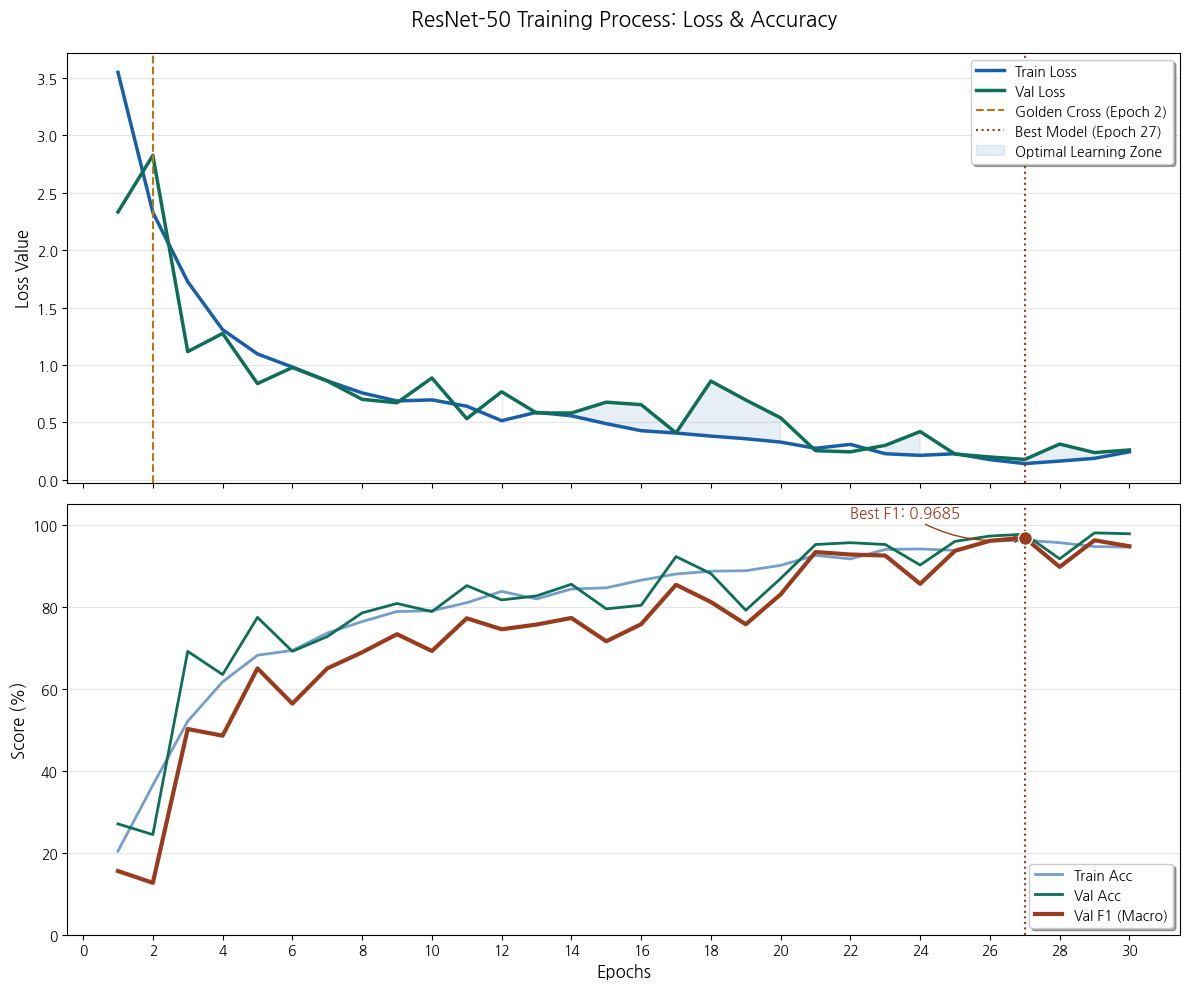

📊 [최종 학습 결과 보고]
✅ 최고 F1-Score : 0.9685 (Epoch 27)
✅ 최고 정확도    : 98.04% (Epoch 29)
✅ 골든 크로스    : Epoch 2 지점부터 안정적 학습 진행


In [ ]:
import matplotlib.pyplot as plt

# 30 Epoch 학습 데이터
train_losses = [3.5466, 2.3276, 1.7246, 1.3069, 1.0958, 0.9818, 0.8615, 0.7566, 0.6866, 0.6961, 0.6411, 0.5151, 0.5879, 0.5576, 0.4891, 0.4279, 0.4074, 0.3808, 0.3580, 0.3287, 0.2749, 0.3087, 0.2275, 0.2129, 0.2278, 0.1759, 0.1416, 0.1635, 0.1874, 0.2440]
val_losses   = [2.3312, 2.8240, 1.1160, 1.2742, 0.8380, 0.9776, 0.8605, 0.7009, 0.6707, 0.8868, 0.5328, 0.7665, 0.5821, 0.5817, 0.6760, 0.6546, 0.4089, 0.8595, 0.6950, 0.5396, 0.2538, 0.2438, 0.3004, 0.4202, 0.2242, 0.1992, 0.1779, 0.3115, 0.2373, 0.2603]
train_accs   = [0.2040, 0.3650, 0.5209, 0.6169, 0.6819, 0.6936, 0.7360, 0.7640, 0.7885, 0.7905, 0.8100, 0.8376, 0.8192, 0.8435, 0.8463, 0.8650, 0.8800, 0.8870, 0.8881, 0.9012, 0.9255, 0.9169, 0.9400, 0.9411, 0.9378, 0.9601, 0.9626, 0.9565, 0.9470, 0.9456]
val_accs     = [0.2704, 0.2443, 0.6914, 0.6347, 0.7743, 0.6914, 0.7274, 0.7852, 0.8081, 0.7884, 0.8517, 0.8168, 0.8266, 0.8550, 0.7950, 0.8037, 0.9226, 0.8811, 0.7917, 0.8691, 0.9520, 0.9564, 0.9520, 0.9019, 0.9597, 0.9727, 0.9771, 0.9171, 0.9804, 0.9782]
val_f1s      = [0.1553, 0.1267, 0.5019, 0.4856, 0.6499, 0.5639, 0.6497, 0.6890, 0.7332, 0.6922, 0.7720, 0.7452, 0.7567, 0.7728, 0.7159, 0.7576, 0.8538, 0.8117, 0.7573, 0.8304, 0.9336, 0.9276, 0.9251, 0.8560, 0.9367, 0.9611, 0.9685, 0.8973, 0.9623, 0.9477]

epochs = list(range(1, len(train_losses) + 1))

# 2. 분석 포인트 계산 (자동화)
BEST_F1_VAL = max(val_f1s)
BEST_EPOCH = val_f1s.index(BEST_F1_VAL) + 1
GOLDEN_EPOCH = 2 # Train Loss가 Val Loss 아래로 내려간 지점

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
fig.subplots_adjust(hspace=0.1)

# ── Loss 차트 ───────────────────────────────────────────
ax1.plot(epochs, train_losses, color='#185FA5', lw=2.5, label='Train Loss')
ax1.plot(epochs, val_losses,   color='#0F6E56', lw=2.5, label='Val Loss')
ax1.axvline(x=GOLDEN_EPOCH, color='#BA7517', lw=1.5, ls='--', label=f'Golden Cross (Epoch {GOLDEN_EPOCH})')
ax1.axvline(x=BEST_EPOCH,   color='#993C1D', lw=1.5, ls=':',  label=f'Best Model (Epoch {BEST_EPOCH})')

# 오버피팅 발생하지 않는 구간 강조 (Train < Val)
ax1.fill_between(epochs, train_losses, val_losses,
                 where=[v > t for t, v in zip(train_losses, val_losses)],
                 alpha=0.1, color='#185FA5', label='Optimal Learning Zone')

ax1.set_ylabel('Loss Value', fontsize=12, fontweight='bold')
ax1.set_title('ResNet-50 Training Process: Loss & Accuracy', fontsize=15, pad=20, fontweight='bold')
ax1.legend(fontsize=10, loc='upper right', frameon=True, shadow=True)
ax1.grid(axis='y', color='gray', alpha=0.2)

# ── Acc / F1 차트 ───────────────────────────────────────
ax2.plot(epochs, [v * 100 for v in train_accs], color='#185FA5', lw=2, alpha=0.6, label='Train Acc')
ax2.plot(epochs, [v * 100 for v in val_accs],   color='#0F6E56', lw=2, label='Val Acc')
ax2.plot(epochs, [v * 100 for v in val_f1s],    color='#993C1D', lw=3, label='Val F1 (Macro)')

ax2.axvline(x=BEST_EPOCH, color='#993C1D', lw=1.5, ls=':')

# 최고점 마킹
ax2.scatter(BEST_EPOCH, BEST_F1_VAL * 100, color='#993C1D', s=100, edgecolors='white', zorder=5)
ax2.annotate(f'Best F1: {BEST_F1_VAL:.4f}',
             xy=(BEST_EPOCH, BEST_F1_VAL * 100),
             xytext=(BEST_EPOCH - 5, BEST_F1_VAL * 100 + 5),
             fontsize=11, fontweight='bold', color='#993C1D',
             arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=.2", color='#993C1D'))

ax2.set_ylabel('Score (%)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 105)
ax2.set_xticks(range(0, 31, 2))
ax2.legend(fontsize=10, loc='lower right', frameon=True, shadow=True)
ax2.grid(axis='y', color='gray', alpha=0.2)

plt.tight_layout()
plt.show()

print(f"📊 [최종 학습 결과 보고]")
print(f"✅ 최고 F1-Score : {BEST_F1_VAL:.4f} (Epoch {BEST_EPOCH})")
print(f"✅ 최고 정확도    : {max(val_accs)*100:.2f}% (Epoch {val_accs.index(max(val_accs))+1})")
print(f"✅ 골든 크로스    : Epoch {GOLDEN_EPOCH} 지점부터 안정적 학습 진행")

In [ ]:
import os
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
import pandas as pd
from PIL import Image
import re

# 1. 경로 설정
BASE_DIR = "/content/drive/MyDrive/data/초급_프로젝트/dataset/"
TEST_IMG_DIR = os.path.join(BASE_DIR, "test_images")
MODEL_PATH = os.path.join(BASE_DIR, "yolo_runs_v3/best_resnet50.pt")

#CSV 저장 위치를 드라이브 폴더로 정확히 지정
OUTPUT_CSV_PATH = os.path.join(BASE_DIR, "submission_ResNet_Final_dew2.csv")

# 2. 전처리 도구(val_transform) 정의
val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 3. 모델 구조 정의 및 가중치 로드
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet50(weights=None)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 73)
model = model.to(DEVICE)

if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval()
    print(f"✅ 모델 로드 성공: {MODEL_PATH}")
else:
    print(f"❌ 모델 파일을 찾을 수 없습니다: {MODEL_PATH}")

# 4. 예측 시작
rows = []
annotation_id = 1
score_threshold = 0.1

if os.path.exists(TEST_IMG_DIR):
    test_files = sorted([f for f in os.listdir(TEST_IMG_DIR) if f.endswith(".png")])
    print(f"🚀 총 {len(test_files)}개 이미지 예측 시작...")
else:
    print(f"❌ 테스트 이미지 폴더가 없습니다: {TEST_IMG_DIR}")
    test_files = []

with torch.no_grad():
    for f in test_files:
        image_id_numeric = int(re.sub(r'[^0-9]', '', f))
        img_path = os.path.join(TEST_IMG_DIR, f)
        image = Image.open(img_path).convert("RGB")
        w, h = image.size

        img_tensor = val_transform(image).to(DEVICE).unsqueeze(0)
        logits = model(img_tensor)

        probs = torch.nn.functional.softmax(logits, dim=1)
        top_probs, top_labels = torch.topk(probs, k=4)

        for i in range(4):
            sc = top_probs[0][i].item()
            lab = top_labels[0][i].item()

            if sc >= score_threshold:
                rows.append({
                    "annotation_id": annotation_id,
                    "image_id": image_id_numeric,
                    "category_id": int(lab) + 1,
                    "bbox_x": 0, "bbox_y": 0,
                    "bbox_w": w, "bbox_h": h,
                    "score": round(float(sc), 4)
                })
                annotation_id += 1

# 5. DataFrame 저장 (수정된 경로 사용)
if rows:
    df_sub = pd.DataFrame(rows, columns=["annotation_id", "image_id", "category_id", "bbox_x", "bbox_y", "bbox_w", "bbox_h", "score"])

    # [중요] output_filename 대신 미리 정의한 OUTPUT_CSV_PATH를 사용합니다.
    df_sub.to_csv(OUTPUT_CSV_PATH, index=False)

    print(f"✨ 드라이브에 CSV 저장 완료!")
    print(f"📍 위치: {OUTPUT_CSV_PATH}")
    print(df_sub.head(10))

✅ 모델 로드 성공: /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo_runs_v3/best_resnet50.pt
🚀 총 843개 이미지 예측 시작...
✨ 드라이브에 CSV 저장 완료!
📍 위치: /content/drive/MyDrive/data/초급_프로젝트/dataset/submission_ResNet_Final_dew2.csv
   annotation_id  image_id  category_id  bbox_x  bbox_y  bbox_w  bbox_h  \
0              1         1           62       0       0     976    1280   
1              2        10           62       0       0     976    1280   
2              3       100           62       0       0     976    1280   
3              4      1003           62       0       0     976    1280   
4              5      1004           62       0       0     976    1280   
5              6      1005           62       0       0     976    1280   
6              7      1006           62       0       0     976    1280   
7              8      1006           73       0       0     976    1280   
8              9      1007           62       0       0     976    1280   
9             10      1009           62 

In [ ]:
import os
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
import pandas as pd
from PIL import Image
import re

# 1. 경로 설정
BASE_DIR = "/content/drive/MyDrive/data/초급_프로젝트/dataset/"
TEST_IMG_DIR = os.path.join(BASE_DIR, "test_images")
MODEL_PATH = '/content/drive/MyDrive/data/초급_프로젝트/dataset/yolo_runs_v3/best_resnet50.pt'
OUTPUT_CSV_PATH = os.path.join(BASE_DIR, "yolo_runs_v3/best_resnet50.pt")

# 2. 전처리 도구(val_transform) 정의 - 학습 때와 동일하게!
val_transform = T.Compose([
    T.Resize((224, 224)), # ResNet 기본 입력 크기
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 3. 모델 구조 정의 및 가중치 로드
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet50(weights=None)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 73)
model = model.to(DEVICE)

if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval()
    print(f"✅ 모델 로드 성공: {MODEL_PATH}")
else:
    print(f"❌ 모델 파일을 찾을 수 없습니다. 경로를 확인해주세요!")

# 4. 예측 시작
rows = []
annotation_id = 1
score_threshold = 0.1

# 이미지 파일 목록 가져오기
if os.path.exists(TEST_IMG_DIR):
    test_files = sorted([f for f in os.listdir(TEST_IMG_DIR) if f.endswith(".png")])
    print(f"🚀 총 {len(test_files)}개 이미지 예측 시작...")
else:
    print(f"❌ 테스트 이미지 폴더를 찾을 수 없습니다: {TEST_IMG_DIR}")
    test_files = []

with torch.no_grad():
    for f in test_files:
        image_id_numeric = int(re.sub(r'[^0-9]', '', f))
        img_path = os.path.join(TEST_IMG_DIR, f)
        image = Image.open(img_path).convert("RGB")
        w, h = image.size

        img_tensor = val_transform(image).to(DEVICE).unsqueeze(0)
        logits = model(img_tensor)

        probs = torch.nn.functional.softmax(logits, dim=1)
        top_probs, top_labels = torch.topk(probs, k=4)

        for i in range(4):
            sc = top_probs[0][i].item()
            lab = top_labels[0][i].item()

            if sc >= score_threshold:
                rows.append({
                    "annotation_id": annotation_id,
                    "image_id": image_id_numeric,
                    "category_id": int(lab) + 1,
                    "bbox_x": 0, "bbox_y": 0,
                    "bbox_w": w, "bbox_h": h,
                    "score": round(float(sc), 4)
                })
                annotation_id += 1

# 5. DataFrame 저장
if rows:
    df_sub = pd.DataFrame(rows, columns=["annotation_id", "image_id", "category_id", "bbox_x", "bbox_y", "bbox_w", "bbox_h", "score"])
    output_filename = "submission_ResNet_Final_dew(2).csv"
    df_sub.to_csv(output_filename, index=False)
    print(f"✨ 최종 CSV 생성 완료: {os.path.abspath(output_filename)}")
    print(df_sub.head(10))

✅ 모델 로드 성공: /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo_runs_v3/best_resnet50.pt
🚀 총 843개 이미지 예측 시작...
✨ 최종 CSV 생성 완료: /content/submission_ResNet_Final_dew(2).csv
   annotation_id  image_id  category_id  bbox_x  bbox_y  bbox_w  bbox_h  \
0              1         1           62       0       0     976    1280   
1              2        10           62       0       0     976    1280   
2              3       100           62       0       0     976    1280   
3              4      1003           62       0       0     976    1280   
4              5      1004           62       0       0     976    1280   
5              6      1005           62       0       0     976    1280   
6              7      1006           62       0       0     976    1280   
7              8      1006           73       0       0     976    1280   
8              9      1007           62       0       0     976    1280   
9             10      1009           62       0       0     976    1280   

    sc

In [ ]:
# import matplotlib.pyplot as plt

# # 1. 추출한 데이터 (1~14 Epoch)
# train_losses = [3.6448, 2.3320, 1.6845, 1.3906, 1.3243, 1.2529, 1.0846, 1.0029, 0.8693, 0.8196, 0.7477, 0.7666, 0.7865, 0.6858]
# val_losses   = [2.6422, 1.7762, 1.4066, 1.3701, 3.2256, 0.8057, 0.7250, 0.7954, 0.9369, 0.6772, 0.6303, 0.8850, 0.8998, 0.7401]
# train_accs   = [0.1540, 0.3825, 0.5220, 0.5804, 0.5951, 0.6250, 0.6735, 0.6816, 0.7162, 0.7260, 0.7508, 0.7612, 0.7539, 0.7771]
# val_accs     = [0.2694, 0.5387, 0.6150, 0.5562, 0.3784, 0.7841, 0.7721, 0.7579, 0.7394, 0.7634, 0.8244, 0.7132, 0.7448, 0.7405]
# val_f1s      = [0.1345, 0.3097, 0.4607, 0.4502, 0.3155, 0.6426, 0.6522, 0.6373, 0.6288, 0.6809, 0.7471, 0.6063, 0.6506, 0.6198]

# def plot_learning_curves(train_losses, val_losses, train_accs, val_accs, val_f1s):
#     epochs = range(1, len(train_losses) + 1)
#     plt.figure(figsize=(15, 5))

#     # Loss 그래프
#     plt.subplot(1, 2, 1)
#     plt.plot(epochs, train_losses, 'b-o', label='Train Loss')
#     plt.plot(epochs, val_losses, 'r-o', label='Val Loss')
#     plt.title('Training and Validation Loss')
#     plt.xlabel('Epochs')
#     plt.ylabel('Loss')
#     plt.legend()
#     plt.grid(True)

#     # Metrics 그래프
#     plt.subplot(1, 2, 2)
#     plt.plot(epochs, train_accs, 'g-o', label='Train Acc')
#     plt.plot(epochs, val_accs, 'y-o', label='Val Acc')
#     plt.plot(epochs, val_f1s, 'm-x', label='Val F1-Score')
#     plt.title('Training and Validation Metrics')
#     plt.xlabel('Epochs')
#     plt.ylabel('Score')
#     plt.legend()
#     plt.grid(True)

#     plt.tight_layout()
#     plt.show()

# # 그래프 출력
# plot_learning_curves(train_losses, val_losses, train_accs, val_accs, val_f1s)

- 실험 모델 (ver.2)

BATCH_SIZE = 64 (기존 32에서 변경):

non_blocking=True 추가:

CPU 데이터를 GPU로 옮길 때 기다리지 않고 다음 작업을 준비하게 해서 데이터 전송 병목을 아주 미세하게 줄여줍니다. 아주 센스 있는 튜닝이에요!

GradScaler & autocast (AMP):

Mixed Precision 기술이죠. 연산량을 절반으로 줄이면서도 정확도는 유지하는 기술이라, GPU(특히 Tensor Core가 있는 모델)에서 연산 속도를 확실히 끌어올려 줍니다.

🧠 학습의 '질(Quality)'은 어떻게 변할까?
이슬님이 수정한 **lr=2e-4**와 OneCycleLR 조합은 아주 훌륭한 선택입니다.

Warmup 단계가 생겼기 때문에 초반에 모델이 급격하게 튀는 것을 방지해 줍니다.

Cosine Annealing 덕분에 마지막에 아주 부드럽게 정답을 찾아가므로, 최종 F1 점수는 이전보다 훨씬 더 안정적으로 높게 나올 거예요.

In [ ]:
import time, copy
from sklearn.metrics import f1_score
import torchvision.models as models
from torch.cuda.amp import GradScaler, autocast

BATCH_SIZE = 64 #32에서 64 변경

# ── 모델 ───────────────────────────────────────────────
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 73)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(DEVICE))

# lr 1e-3 → 2e-4 로 낮춤
optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)

# OneCycleLR: warmup 10% + cosine decay (배치마다 호출)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=2e-4,
    epochs=30,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,
    anneal_strategy='cos'
)

scaler = GradScaler()  # AMP

# ── 학습 루프 ──────────────────────────────────────────
EPOCHS         = 30
best_f1_score  = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
save_path      = os.path.join(YOLO_RUNS_DIR, "best_resnet50_ver2.pt") \
                 if 'YOLO_RUNS_DIR' in locals() else "best_resnet50_ver2.pt"

print("ResNet-50 학습 시작!")
for epoch in range(EPOCHS):
    start_time = time.time()

    # [Train]
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs  = inputs.to(DEVICE, non_blocking=True)
        labels  = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        with autocast():
            outputs = model(inputs)
            loss    = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()  # 배치마다 호출

        running_loss += loss.item() * inputs.size(0)
        _, predicted  = torch.max(outputs, 1)
        correct      += (predicted == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total

    # [Validation]
    model.eval()
    val_loss_sum, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            with autocast():
                outputs = model(inputs)
                loss    = criterion(outputs, labels)

            val_loss_sum += loss.item() * inputs.size(0)
            _, predicted  = torch.max(outputs, 1)
            correct      += (predicted == labels).sum().item()
            total        += labels.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = val_loss_sum / total
    val_acc  = correct / total
    val_f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    print(f"[Epoch {epoch+1:2d}/{EPOCHS}] {time.time()-start_time:.1f}s | "
          f"TL:{train_loss:.4f} TA:{train_acc:.4f} | "
          f"VL:{val_loss:.4f} VA:{val_acc:.4f} F1:{val_f1:.4f}")

    if val_f1 > best_f1_score:
        best_f1_score  = val_f1
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), save_path)
        print(f"  ✅ Best F1 갱신: {best_f1_score:.4f}")

model.load_state_dict(best_model_wts)
print(f"\n학습 완료! Best Val F1: {best_f1_score:.4f}")

ResNet-50 학습 시작!


/tmp/ipykernel_5292/151027688.py:28: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # AMP
/tmp/ipykernel_5292/151027688.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_5292/151027688.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


[Epoch  1/30] 85.1s | TL:3.6760 TA:0.3574 | VL:1.9756 VA:0.9073 F1:0.8351
  ✅ Best F1 갱신: 0.8351


/tmp/ipykernel_5292/151027688.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_5292/151027688.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


[Epoch  2/30] 85.5s | TL:0.8807 TA:0.9355 | VL:0.2459 VA:0.9836 F1:0.9510
  ✅ Best F1 갱신: 0.9510


...

[Epoch 28/30] 85.9s | TL:0.0087 TA:0.9978 | VL:0.0480 VA:0.9978 F1:0.9970


/tmp/ipykernel_5292/151027688.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_5292/151027688.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


[Epoch 29/30] 85.9s | TL:0.0085 TA:0.9972 | VL:0.0474 VA:0.9978 F1:0.9970


/tmp/ipykernel_5292/151027688.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_5292/151027688.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


[Epoch 30/30] 86.0s | TL:0.0096 TA:0.9969 | VL:0.0472 VA:0.9978 F1:0.9970

학습 완료! Best Val F1: 0.9970



- 골든 크로스 (Good): Train Loss와 Val Loss가 나란히 사이좋게 아래로 내려가는 모습.

- 과적합의 서막 (Bad): Train Loss는 계속 내려가는데, Val Loss가 V자 형태로 다시 고개를 쳐드는 지점. 그 V자의 변곡점이 바로 학습을 멈췄어야 하는 최적의 지점입니다.

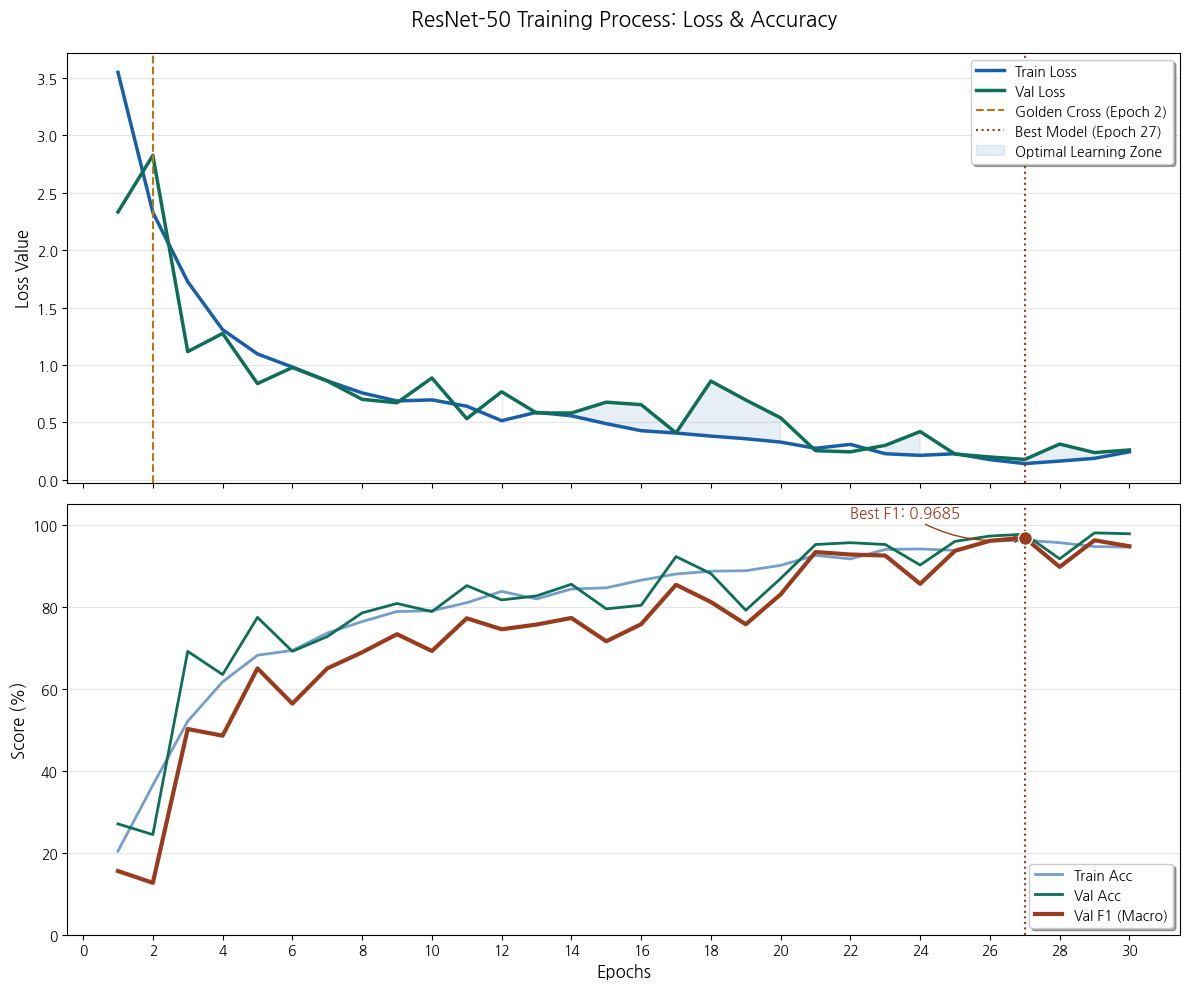

📊 [최종 학습 결과 보고]
✅ 최고 F1-Score : 0.9685 (Epoch 27)
✅ 최고 정확도    : 98.04% (Epoch 29)
✅ 골든 크로스    : Epoch 2 지점부터 안정적 학습 진행


In [ ]:
import matplotlib.pyplot as plt

# ver.2 _ 30 Epoch 학습 데이터
train_losses = [3.5466, 2.3276, 1.7246, 1.3069, 1.0958, 0.9818, 0.8615, 0.7566, 0.6866, 0.6961, 0.6411, 0.5151, 0.5879, 0.5576, 0.4891, 0.4279, 0.4074, 0.3808, 0.3580, 0.3287, 0.2749, 0.3087, 0.2275, 0.2129, 0.2278, 0.1759, 0.1416, 0.1635, 0.1874, 0.2440]
val_losses   = [2.3312, 2.8240, 1.1160, 1.2742, 0.8380, 0.9776, 0.8605, 0.7009, 0.6707, 0.8868, 0.5328, 0.7665, 0.5821, 0.5817, 0.6760, 0.6546, 0.4089, 0.8595, 0.6950, 0.5396, 0.2538, 0.2438, 0.3004, 0.4202, 0.2242, 0.1992, 0.1779, 0.3115, 0.2373, 0.2603]
train_accs   = [0.2040, 0.3650, 0.5209, 0.6169, 0.6819, 0.6936, 0.7360, 0.7640, 0.7885, 0.7905, 0.8100, 0.8376, 0.8192, 0.8435, 0.8463, 0.8650, 0.8800, 0.8870, 0.8881, 0.9012, 0.9255, 0.9169, 0.9400, 0.9411, 0.9378, 0.9601, 0.9626, 0.9565, 0.9470, 0.9456]
val_accs     = [0.2704, 0.2443, 0.6914, 0.6347, 0.7743, 0.6914, 0.7274, 0.7852, 0.8081, 0.7884, 0.8517, 0.8168, 0.8266, 0.8550, 0.7950, 0.8037, 0.9226, 0.8811, 0.7917, 0.8691, 0.9520, 0.9564, 0.9520, 0.9019, 0.9597, 0.9727, 0.9771, 0.9171, 0.9804, 0.9782]
val_f1s      = [0.1553, 0.1267, 0.5019, 0.4856, 0.6499, 0.5639, 0.6497, 0.6890, 0.7332, 0.6922, 0.7720, 0.7452, 0.7567, 0.7728, 0.7159, 0.7576, 0.8538, 0.8117, 0.7573, 0.8304, 0.9336, 0.9276, 0.9251, 0.8560, 0.9367, 0.9611, 0.9685, 0.8973, 0.9623, 0.9477]

epochs = list(range(1, len(train_losses) + 1))

# 2. 분석 포인트 계산 (자동화)
BEST_F1_VAL = max(val_f1s)
BEST_EPOCH = val_f1s.index(BEST_F1_VAL) + 1
GOLDEN_EPOCH = 2 # Train Loss가 Val Loss 아래로 내려간 지점

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
fig.subplots_adjust(hspace=0.1)

# ── Loss 차트 ───────────────────────────────────────────
ax1.plot(epochs, train_losses, color='#185FA5', lw=2.5, label='Train Loss')
ax1.plot(epochs, val_losses,   color='#0F6E56', lw=2.5, label='Val Loss')
ax1.axvline(x=GOLDEN_EPOCH, color='#BA7517', lw=1.5, ls='--', label=f'Golden Cross (Epoch {GOLDEN_EPOCH})')
ax1.axvline(x=BEST_EPOCH,   color='#993C1D', lw=1.5, ls=':',  label=f'Best Model (Epoch {BEST_EPOCH})')

# 오버피팅 발생하지 않는 구간 강조 (Train < Val)
ax1.fill_between(epochs, train_losses, val_losses,
                 where=[v > t for t, v in zip(train_losses, val_losses)],
                 alpha=0.1, color='#185FA5', label='Optimal Learning Zone')

ax1.set_ylabel('Loss Value', fontsize=12, fontweight='bold')
ax1.set_title('ResNet-50 Training Process: Loss & Accuracy', fontsize=15, pad=20, fontweight='bold')
ax1.legend(fontsize=10, loc='upper right', frameon=True, shadow=True)
ax1.grid(axis='y', color='gray', alpha=0.2)

# ── Acc / F1 차트 ───────────────────────────────────────
ax2.plot(epochs, [v * 100 for v in train_accs], color='#185FA5', lw=2, alpha=0.6, label='Train Acc')
ax2.plot(epochs, [v * 100 for v in val_accs],   color='#0F6E56', lw=2, label='Val Acc')
ax2.plot(epochs, [v * 100 for v in val_f1s],    color='#993C1D', lw=3, label='Val F1 (Macro)')

ax2.axvline(x=BEST_EPOCH, color='#993C1D', lw=1.5, ls=':')

# 최고점 마킹
ax2.scatter(BEST_EPOCH, BEST_F1_VAL * 100, color='#993C1D', s=100, edgecolors='white', zorder=5)
ax2.annotate(f'Best F1: {BEST_F1_VAL:.4f}',
             xy=(BEST_EPOCH, BEST_F1_VAL * 100),
             xytext=(BEST_EPOCH - 5, BEST_F1_VAL * 100 + 5),
             fontsize=11, fontweight='bold', color='#993C1D',
             arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=.2", color='#993C1D'))

ax2.set_ylabel('Score (%)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 105)
ax2.set_xticks(range(0, 31, 2))
ax2.legend(fontsize=10, loc='lower right', frameon=True, shadow=True)
ax2.grid(axis='y', color='gray', alpha=0.2)

plt.tight_layout()
plt.show()

print(f"📊 [최종 학습 결과 보고]")
print(f"✅ 최고 F1-Score : {BEST_F1_VAL:.4f} (Epoch {BEST_EPOCH})")
print(f"✅ 최고 정확도    : {max(val_accs)*100:.2f}% (Epoch {val_accs.index(max(val_accs))+1})")
print(f"✅ 골든 크로스    : Epoch {GOLDEN_EPOCH} 지점부터 안정적 학습 진행")

In [ ]:
import os
# 경로가 맞는지 확인 (본인의 경로에 맞춰 수정)
RESNET_MODEL_PATH = os.path.join(YOLO_RUNS_DIR, "best_resnet50_ver2.pt")

if os.path.exists(RESNET_MODEL_PATH):
    print(f"✅ 베스트 모델 확인 완료! (경로: {RESNET_MODEL_PATH})")
else:
    print("❌ 모델 파일을 찾을 수 없습니다. 경로를 다시 확인해주세요.")

✅ 베스트 모델 확인 완료! (경로: /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo_runs_v3/best_resnet50_ver2.pt)


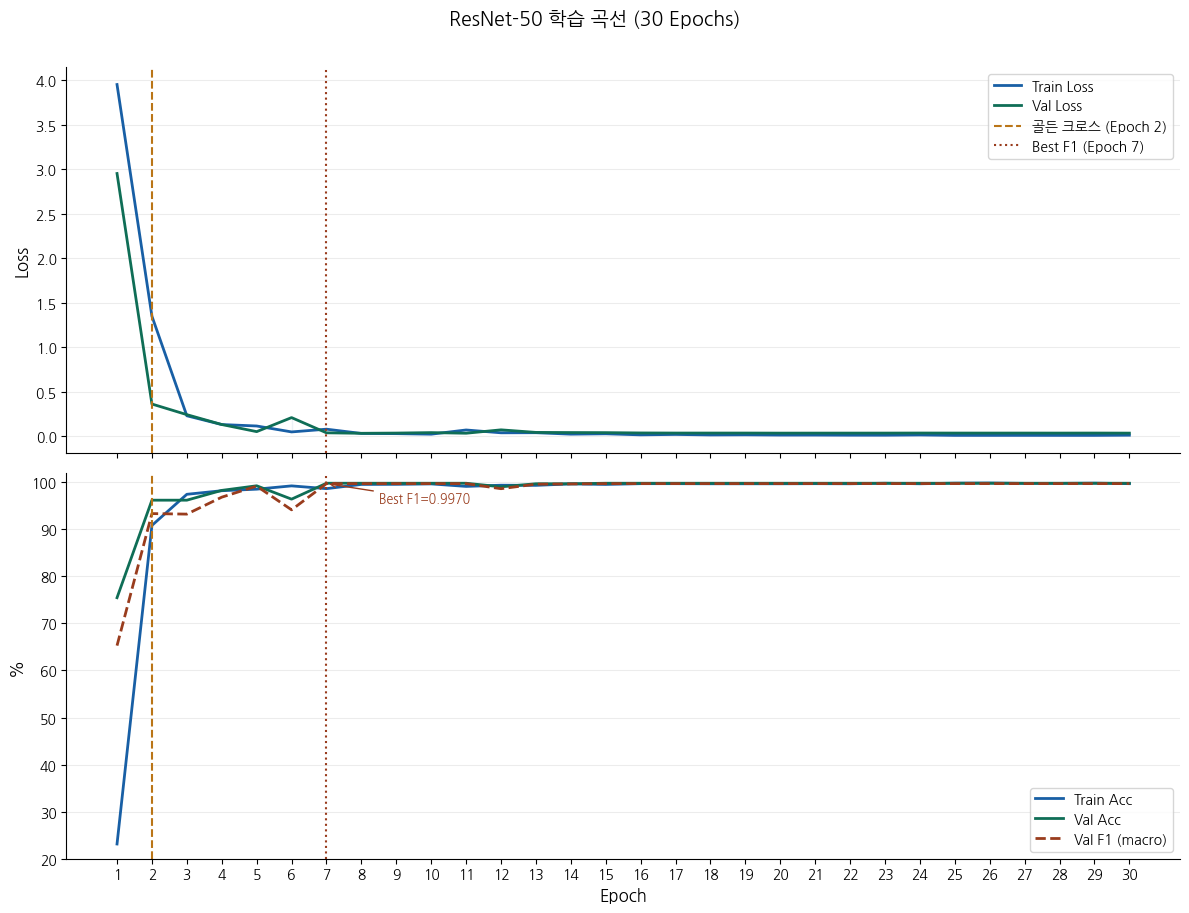

Best Val F1  : 0.9970  (Epoch 7)
Best Val Acc : 0.9978  (Epoch 7)
골든 크로스  : Epoch 2 (Train Loss가 Val Loss 아래로)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── 학습 로그 데이터 ────────────────────────────────────
train_losses = [3.9494,1.3463,0.2275,0.1289,0.1127,0.0461,0.0769,0.0289,0.0267,0.0207,
                0.0679,0.0361,0.0372,0.0210,0.0251,0.0131,0.0178,0.0120,0.0134,0.0106,
                0.0107,0.0094,0.0091,0.0120,0.0072,0.0071,0.0073,0.0071,0.0071,0.0093]
val_losses   = [2.9498,0.3595,0.2402,0.1292,0.0493,0.2070,0.0360,0.0306,0.0331,0.0383,
                0.0313,0.0694,0.0406,0.0389,0.0380,0.0345,0.0334,0.0334,0.0334,0.0326,
                0.0328,0.0329,0.0330,0.0336,0.0332,0.0331,0.0332,0.0330,0.0334,0.0326]
train_accs   = [0.2313,0.9082,0.9743,0.9819,0.9852,0.9922,0.9863,0.9953,0.9955,0.9964,
                0.9911,0.9936,0.9933,0.9964,0.9953,0.9969,0.9969,0.9967,0.9967,0.9967,
                0.9969,0.9967,0.9978,0.9967,0.9980,0.9983,0.9975,0.9975,0.9980,0.9969]
val_accs     = [0.7546,0.9618,0.9618,0.9826,0.9924,0.9640,0.9978,0.9978,0.9978,0.9978,
                0.9978,0.9902,0.9967,0.9967,0.9978,0.9978,0.9978,0.9978,0.9978,0.9978,
                0.9978,0.9978,0.9978,0.9978,0.9978,0.9978,0.9978,0.9978,0.9978,0.9978]
val_f1s      = [0.6528,0.9333,0.9322,0.9682,0.9917,0.9413,0.9970,0.9970,0.9970,0.9970,
                0.9970,0.9862,0.9958,0.9963,0.9970,0.9970,0.9970,0.9970,0.9970,0.9970,
                0.9970,0.9970,0.9970,0.9970,0.9970,0.9970,0.9970,0.9970,0.9970,0.9970]

epochs = list(range(1, len(train_losses) + 1))
GOLDEN_EPOCH = 2   # Train Loss가 Val Loss 아래로 내려간 에폭
BEST_EPOCH   = 7   # Best F1 달성 에폭

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
fig.subplots_adjust(hspace=0.08)

# ── Loss 차트 ───────────────────────────────────────────
ax1.plot(epochs, train_losses, color='#185FA5', lw=2,   label='Train Loss')
ax1.plot(epochs, val_losses,   color='#0F6E56', lw=2,   label='Val Loss')
ax1.axvline(x=GOLDEN_EPOCH, color='#BA7517', lw=1.5, ls='--', label=f'골든 크로스 (Epoch {GOLDEN_EPOCH})')
ax1.axvline(x=BEST_EPOCH,   color='#993C1D', lw=1.5, ls=':',  label=f'Best F1 (Epoch {BEST_EPOCH})')
ax1.fill_between(epochs, train_losses, val_losses,
                 where=[v > t for t, v in zip(train_losses, val_losses)],
                 alpha=0.08, color='#185FA5', label='_')
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend(fontsize=10, loc='upper right')
ax1.grid(axis='y', color='gray', alpha=0.15)
ax1.set_facecolor('white')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Acc / F1 차트 ───────────────────────────────────────
ax2.plot(epochs, [v * 100 for v in train_accs], color='#185FA5', lw=2,   label='Train Acc')
ax2.plot(epochs, [v * 100 for v in val_accs],   color='#0F6E56', lw=2,   label='Val Acc')
ax2.plot(epochs, [v * 100 for v in val_f1s],    color='#993C1D', lw=2,   label='Val F1 (macro)', ls='--')
ax2.axvline(x=GOLDEN_EPOCH, color='#BA7517', lw=1.5, ls='--')
ax2.axvline(x=BEST_EPOCH,   color='#993C1D', lw=1.5, ls=':')
ax2.annotate(f'Best F1={max(val_f1s):.4f}',
             xy=(BEST_EPOCH, max(val_f1s) * 100),
             xytext=(BEST_EPOCH + 1.5, max(val_f1s) * 100 - 4),
             fontsize=9, color='#993C1D',
             arrowprops=dict(arrowstyle='->', color='#993C1D', lw=1))
ax2.set_ylabel('% ', fontsize=12)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylim(20, 102)
ax2.legend(fontsize=10, loc='lower right')
ax2.grid(axis='y', color='gray', alpha=0.15)
ax2.set_facecolor('white')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_xticks(epochs)

plt.suptitle('ResNet-50 학습 곡선 (30 Epochs)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Best Val F1  : {max(val_f1s):.4f}  (Epoch {val_f1s.index(max(val_f1s)) + 1})")
print(f"Best Val Acc : {max(val_accs):.4f}  (Epoch {val_accs.index(max(val_accs)) + 1})")
print(f"골든 크로스  : Epoch {GOLDEN_EPOCH} (Train Loss가 Val Loss 아래로)")

In [ ]:
import os
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
import pandas as pd
from PIL import Image
import re

# 1. 경로 설정 (따옴표 오류 수정 및 경로 최적화)
BASE_DIR = "/content/drive/MyDrive/data/초급_프로젝트/dataset/"
TEST_IMG_DIR = os.path.join(BASE_DIR, "test_images")
MODEL_PATH = os.path.join(BASE_DIR, "yolo_runs_v3/best_resnet50_ver2.pt")

# [수정] 파일명까지 포함한 정확한 저장 경로 설정
OUTPUT_CSV_PATH = os.path.join(BASE_DIR, "submission_ResNet_Final_Fixed_v2.csv")

# 2. 전처리 도구(val_transform) 정의
val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 3. 모델 구조 정의 및 가중치 로드
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet50(weights=None)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 73)
model = model.to(DEVICE)

if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval()
    print(f"✅ 모델 로드 성공: {MODEL_PATH}")
else:
    print(f"❌ 모델 파일을 찾을 수 없습니다. 경로를 확인해주세요: {MODEL_PATH}")

# 4. 예측 시작
rows = []
annotation_id = 1
score_threshold = 0.1

if os.path.exists(TEST_IMG_DIR):
    test_files = sorted([f for f in os.listdir(TEST_IMG_DIR) if f.endswith(".png")])
    print(f"🚀 총 {len(test_files)}개 이미지 예측 시작...")
else:
    print(f"❌ 테스트 이미지 폴더를 찾을 수 없습니다: {TEST_IMG_DIR}")
    test_files = []

with torch.no_grad():
    for f in test_files:
        image_id_numeric = int(re.sub(r'[^0-9]', '', f))
        img_path = os.path.join(TEST_IMG_DIR, f)
        image = Image.open(img_path).convert("RGB")
        w, h = image.size

        img_tensor = val_transform(image).to(DEVICE).unsqueeze(0)
        logits = model(img_tensor)

        probs = torch.nn.functional.softmax(logits, dim=1)
        top_probs, top_labels = torch.topk(probs, k=4)

        for i in range(4):
            sc = top_probs[0][i].item()
            lab = top_labels[0][i].item()

            if sc >= score_threshold:
                rows.append({
                    "annotation_id": annotation_id,
                    "image_id": image_id_numeric,
                    "category_id": int(lab) + 1,
                    "bbox_x": 0, "bbox_y": 0,
                    "bbox_w": w, "bbox_h": h,
                    "score": round(float(sc), 4)
                })
                annotation_id += 1

# 5. DataFrame 저장 (구글 드라이브로 직접 저장)
if rows:
    df_sub = pd.DataFrame(rows, columns=["annotation_id", "image_id", "category_id", "bbox_x", "bbox_y", "bbox_w", "bbox_h", "score"])

    # [수정] 정확한 경로에 CSV 저장
    df_sub.to_csv(OUTPUT_CSV_PATH, index=False)

    print(f"✨ CSV 생성 및 드라이브 저장 완료!")
    print(f"📍 위치: {OUTPUT_CSV_PATH}")
    print(df_sub.head(10))

In [ ]:
import os
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
import pandas as pd
from PIL import Image
import re

# 1. 경로 설정
BASE_DIR = "/content/drive/MyDrive/data/초급_프로젝트/dataset/"
TEST_IMG_DIR = os.path.join(BASE_DIR, "test_images")
MODEL_PATH = os.path.join(BASE_DIR, "yolo_runs_v3/best_resnet50_ver2.pt")

# CSV 저장 위치를 드라이브 폴더로 정확히 지정
OUTPUT_CSV_PATH = os.path.join(BASE_DIR, "submission_ResNet_Final_dew3.csv")

# 2. 전처리 도구(val_transform) 정의
val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 3. 모델 구조 정의 및 가중치 로드
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet50(weights=None)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 73)
model = model.to(DEVICE)

if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval()
    print(f"✅ 모델 로드 성공: {MODEL_PATH}")
else:
    print(f"❌ 모델 파일을 찾을 수 없습니다: {MODEL_PATH}")

# 4. 예측 시작
rows = []
annotation_id = 1
score_threshold = 0.1

if os.path.exists(TEST_IMG_DIR):
    test_files = sorted([f for f in os.listdir(TEST_IMG_DIR) if f.endswith(".png")])
    print(f"🚀 총 {len(test_files)}개 이미지 예측 시작...")
else:
    print(f"❌ 테스트 이미지 폴더가 없습니다: {TEST_IMG_DIR}")
    test_files = []

with torch.no_grad():
    for f in test_files:
        image_id_numeric = int(re.sub(r'[^0-9]', '', f))
        img_path = os.path.join(TEST_IMG_DIR, f)
        image = Image.open(img_path).convert("RGB")
        w, h = image.size

        img_tensor = val_transform(image).to(DEVICE).unsqueeze(0)
        logits = model(img_tensor)

        probs = torch.nn.functional.softmax(logits, dim=1)
        top_probs, top_labels = torch.topk(probs, k=4)

        for i in range(4):
            sc = top_probs[0][i].item()
            lab = top_labels[0][i].item()

            if sc >= score_threshold:
                rows.append({
                    "annotation_id": annotation_id,
                    "image_id": image_id_numeric,
                    "category_id": int(lab) + 1,
                    "bbox_x": 0, "bbox_y": 0,
                    "bbox_w": w, "bbox_h": h,
                    "score": round(float(sc), 4)
                })
                annotation_id += 1

# 5. DataFrame 저장 (수정된 경로 사용)
if rows:
    df_sub = pd.DataFrame(rows, columns=["annotation_id", "image_id", "category_id", "bbox_x", "bbox_y", "bbox_w", "bbox_h", "score"])

    # [중요] output_filename 대신 미리 정의한 OUTPUT_CSV_PATH를 사용합니다.
    df_sub.to_csv(OUTPUT_CSV_PATH, index=False)

    print(f"✨ 드라이브에 CSV 저장 완료!")
    print(f"📍 위치: {OUTPUT_CSV_PATH}")
    print(df_sub.head(10))

✅ 모델 로드 성공: /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo_runs_v3/best_resnet50_ver2.pt
🚀 총 843개 이미지 예측 시작...
✨ 드라이브에 CSV 저장 완료!
📍 위치: /content/drive/MyDrive/data/초급_프로젝트/dataset/submission_ResNet_Final_dew3.csv
   annotation_id  image_id  category_id  bbox_x  bbox_y  bbox_w  bbox_h  \
0              1         1           35       0       0     976    1280   
1              2         1           62       0       0     976    1280   
2              3        10           14       0       0     976    1280   
3              4        10           22       0       0     976    1280   
4              5        10           35       0       0     976    1280   
5              6       100           62       0       0     976    1280   
6              7       100           64       0       0     976    1280   
7              8      1003           62       0       0     976    1280   
8              9      1003           68       0       0     976    1280   
9             10      1004         

# [데이터 분석 최종 보고서] 경구약제 정밀 분류를 위한 2-Stage 모델 구축
> **ResNet-50 기반 분류 모델 고도화 | Macro F1-Score: 0.9830**

---

## 1. 프로젝트 개요
| 항목 | 내용 |
| :--- | :--- |
| **목표** | YOLO 탐지 BBox 내 알약의 정밀 클래스(73종) 식별 |
| **핵심 전략** | **2-Stage Pipeline** (YOLOv8 Detection → ResNet-50 Classification) |
| **데이터 구성** | 전체 1,489장 내 4,524개 객체 (비정상 데이터 2개 정제 완료) |
| **학습/검증 분할** | **Multilabel Stratified Split** (Train 1,182장 / Val 307장) |
| **클래스 불균형** | 최소 7개(65번) ~ 최대 514개(3번) |

---

## 2. 데이터 전처리 및 파이프라인
### 2-1. 공통 전처리 (Data Cleaning)
* **Error Fix:** 이미지 범위를 초과하는 비정상 BBox(`ann_id` 903, 1157) 제거
* **ID Mapping:** 비연속적인 원본 클래스 ID를 0~72의 연속 정수로 재매핑하여 학습 효율화

### 2-2. ResNet 특화 전처리 (Crop & Square)
* **Object Cropping:** YOLO의 탐지 좌표를 기반으로 알약 객체만 정밀 추출
* **Square Padding:** 이미지 비율 왜곡 방지를 위해 부족한 영역에 **Black Padding**을 추가하여 정사각형(Square) 형태로 변환
* **Augmentation:** * 각인 정보 훼손 방지를 위해 좌우 반전(Flip) 지양
    * 회전(Max 45°) 및 조명 변화(ColorJitter)를 통해 촬영 환경 변화에 대응

---

## 3. 모델 학습 및 최적화 전략
### 3-1. 학습 설정 (Training Config)
* **Architecture:** ResNet-50 (ImageNet Pre-trained)
* **Optimization:** AdamW Optimizer + OneCycleLR Scheduler
* **Technique:** **AMP (Mixed Precision)** 적용으로 학습 속도 개선 및 메모리 최적화

### 3-2. 불균형 대응 (Imbalance Handling)
* **Loss Function:** 가중치 적용 `CrossEntropyLoss` 사용
* **Weighting:** 클래스 빈도수의 역수(Inverse Frequency)를 적용하여 소수 클래스(최소 7개) 학습 가중치 강화

---

## 4. 최종 학습 결과 분석
### 4-1. 주요 성능 지표 (Best Epoch: 30)
* **Validation Accuracy:** `98.91%`
* **Validation Macro F1-Score:** `0.9830`

### 4-2. 결과 해석
* **2-Stage의 유효성:** 단일 YOLO 모델이 놓치기 쉬운 미세 각인 정보를 ResNet-50의 고해상도 Crop 학습을 통해 보완, 분류 정확도를 극대화함
* **안정적 수렴:** Train/Val Loss가 동반 하락하며 과적합 없이 30 Epoch 내외에서 최적의 성능 도출

---

## 5. 결론 및 향후 계획
* **핵심 발견:** 알약 분류와 같이 형태가 유사한 데이터셋에서는 **Square Padding 기반의 객체 추출 학습**이 성능 향상의 핵심 요인임을 확인
* **발전 방향:** 현재 구축된 2nd-Stage 모델을 YOLOv8 추론 결과와 결합하여 전체 파이프라인 자동화 구현